In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

url = "gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2026.zip"

wingx = pd.read_csv(url)
cluster = pd.read_csv("gs://agntworks-data-dev/sandbox/experiments/icao_cluster.csv")
display(wingx.head())
display(cluster.head())

,FlightDate_utc,ArrivalDate_utc,Operator,FromAirport,FromCity,FromState,ToAirport,ToCity,ToState,Hours,aircraft_tailsign,aircraft_tailsign_certification,operator_type,aircraft_icao_code,aircraft_type,aircraft_model,aircraft_segment,fuel_uplift_usg
0,2026-03-31T07:44:00.000Z,2026-03-31T09:20:00.000Z,ProAir Aviation GmbH,LSGG,Geneva,NaN,LHBP,Budapest,NaN,1.600000,DCLIK,Commercial/ CAT / Part 135,Aircraft Management,C25C,Cessna-Citation CJ4,Citation CJ4 Gen2,Light Jet,307.20
1,2026-03-31T20:45:00.000Z,2026-03-31T22:01:00.000Z,CMH Services Aviation Inc,KORL,Orlando,FL,KTYS,Knoxville,TN,1.266667,N74CH,Part 91 / Non Commercial,Private Flight Department,E550,Embraer-Legacy 500 / Praetor 600,Praetor 600,Super Midsize Jet,393.93
2,2026-03-31T14:27:52.000Z,2026-03-31T15:52:44.000Z,Deer Jet,ZSFZ,Fuzhou,35,ZGSZ,Shenzhen,44,1.414444,B8302,Part 91 / Non Commercial,Aircraft Management,GLF5,Gulfstream-GV/500/550,G550,Ultra Long Range Jet,603.97
3,2026-03-31T22:12:30.000Z,2026-04-01T00:13:38.000Z,Beacon Capital Partners LLC,MMSD,Los Cabos,BCS,KSBD,San Bernardino,CA,2.018889,N119AF,Part 91 / Non Commercial,Corporate Flight Department,GLF4,Gulfstream G300/350/400/450,GIV-SP,Heavy Jet,969.07
4,2026-03-31T13:31:00.000Z,2026-03-31T14:13:00.000Z,NetJets,KDAL,Dallas,TX,KDWH,Houston,TX,0.700000,N271QS,Part 91K / Fractional Ownership,Fractional Ownership,E545,Embraer-Legacy 450 / Praetor 500,Praetor 500,Midsize Jet,210.00


,icao,cluster
0,00AA,DENVER_CLUSTER
1,00AK,OTHER_CLUSTER
2,00AL,ATLANTA_CLUSTER
3,00AN,OTHER_CLUSTER
4,00AS,DALLAS_CLUSTER


# rough work

In [129]:
print("Shape:", df.shape)
print(df["Operator"].value_counts())

Shape: (885823, 19)
Operator
NetJets                      111573
Flexjet                       45233
NetJets Europe                13520
Executive Jet Management      11094
flyExclusive                  10457
                              ...  
N225EL-Operator                   1
N794GA-Operator                   1
Alpha Air Enterprises LLC         1
Jetlag Aviation LLC               1
N9MZZZ-Operator                   1
Name: count, Length: 14560, dtype: int64


In [130]:
count = df["Operator"].str.contains("wheels", case=False, na=False).sum()
print(count)

7668


In [131]:
df_wheels = df[df["Operator"].str.contains("wheels up", case=False, na=False)]
df_wheels

,FlightDate_utc,ArrivalDate_utc,Operator,FromAirport,FromCity,FromState,ToAirport,ToCity,ToState,Hours,aircraft_tailsign,aircraft_tailsign_certification,operator_type,aircraft_icao_code,aircraft_type,aircraft_model,aircraft_segment,fuel_uplift_usg,operator_group
85,2026-03-19T15:54:03.000Z,2026-03-19T18:50:56.000Z,Wheels Up Private Jets,KPBI,West Palm Beach,FL,KSAV,Savannah,GA,2.948056,N918TX,Commercial/ CAT / Part 135,Branded Charter,C750,Cessna-Citation X / 10,Citation X,Super Midsize Jet,990.55,Wheels Up
168,2026-03-25T20:18:00.000Z,2026-03-25T22:38:00.000Z,Wheels Up Private Jets,KPSP,Palm Springs,CA,KIXD,Olathe,KS,2.333333,N918TX,Commercial/ CAT / Part 135,Branded Charter,C750,Cessna-Citation X / 10,Citation X,Super Midsize Jet,784.00,Wheels Up
258,2026-03-22T20:45:00.000Z,2026-03-22T22:01:00.000Z,Wheels Up Private Jets,KGPT,Gulfport,MS,KSAV,Savannah,GA,1.266667,N651UP,Part 91 / Non Commercial,Branded Charter,E55P,Embraer-Phenom 300,Phenom 300,Light Jet,217.87,Wheels Up
339,2026-03-19T17:06:00.000Z,2026-03-19T19:48:00.000Z,Wheels Up Private Jets,KCRQ,Carlsbad,CA,KHOU,Houston,TX,2.700000,N906TX,Commercial/ CAT / Part 135,Branded Charter,C750,Cessna-Citation X / 10,Citation X,Super Midsize Jet,907.20,Wheels Up
462,2026-03-05T17:21:00.000Z,2026-03-05T17:50:00.000Z,Wheels Up Private Jets,KTMB,Miami,FL,KAPF,Naples,FL,0.483333,N949UP,Part 91 / Non Commercial,Branded Charter,CL30,Bombardier-Challenger 300 / 350,no model available,Super Midsize Jet,129.05,Wheels Up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885313,2026-01-06T19:38:00.000Z,2026-01-06T20:14:00.000Z,Wheels Up Private Jets,KHOU,Houston,TX,KGGG,Longview,TX,0.600000,N664UP,Part 91 / Non Commercial,Branded Charter,E55P,Embraer-Phenom 300,no model available,Light Jet,103.20,Wheels Up
885320,2026-01-12T15:21:00.000Z,2026-01-12T16:29:00.000Z,Wheels Up Private Jets,KHKS,Jackson,MS,KDAL,Dallas,TX,1.133333,N419TM,Commercial/ CAT / Part 135,Branded Charter,BE40,Hawker Beechjet 400/400A /Nextant,400-XP,Light Jet,242.53,Wheels Up
885321,2026-01-10T00:38:00.000Z,2026-01-10T02:00:00.000Z,Wheels Up Private Jets,KCHS,Charleston,SC,KBNA,Nashville,TN,1.366667,N656UP,Commercial/ CAT / Part 135,Branded Charter,E55P,Embraer-Phenom 300,no model available,Light Jet,235.07,Wheels Up
885340,2026-01-19T12:26:00.000Z,2026-01-19T13:49:00.000Z,Wheels Up Private Jets,KMTH,Marathon,FL,KECP,Panama City,FL,1.383333,N655UP,Commercial/ CAT / Part 135,Branded Charter,E55P,Embraer-Phenom 300,no model available,Light Jet,237.93,Wheels Up


In [132]:
df_wheels.to_csv("wheels_data.csv", index=False)

In [133]:
df_wheel_local = pd.read_csv("wheels_data.csv")
df_wheel_local.sample(10)

,FlightDate_utc,ArrivalDate_utc,Operator,FromAirport,FromCity,FromState,ToAirport,ToCity,ToState,Hours,aircraft_tailsign,aircraft_tailsign_certification,operator_type,aircraft_icao_code,aircraft_type,aircraft_model,aircraft_segment,fuel_uplift_usg,operator_group
4599,2026-01-05T15:13:00.000Z,2026-01-05T17:31:00.000Z,Wheels Up Private Jets,KHPN,White Plains,NY,MYNN,Nassau,NaN,2.300000,N991TX,Commercial/ CAT / Part 135,Branded Charter,C750,Cessna-Citation X / 10,Citation X,Super Midsize Jet,772.80,Wheels Up
2188,2026-03-15T22:27:00.000Z,2026-03-16T00:27:00.000Z,Wheels Up Private Jets,KAFW,Fort Worth,TX,KMTJ,Montrose,CO,2.000000,N653UP,Commercial/ CAT / Part 135,Branded Charter,E55P,Embraer-Phenom 300,Phenom 300,Light Jet,344.00,Wheels Up
7645,2026-01-14T17:18:00.000Z,2026-01-14T20:20:00.000Z,Wheels Up Private Jets,KTEB,Teterboro,NJ,KPBI,West Palm Beach,FL,3.033333,N948UP,Part 91 / Non Commercial,Branded Charter,CL30,Bombardier-Challenger 300 / 350,no model available,Super Midsize Jet,809.90,Wheels Up
793,2026-03-21T18:38:00.000Z,2026-03-21T19:00:00.000Z,Wheels Up Private Jets,KSBA,Santa Barbara,CA,KBUR,Burbank,CA,0.366667,N653UP,Commercial/ CAT / Part 135,Branded Charter,E55P,Embraer-Phenom 300,Phenom 300,Light Jet,63.07,Wheels Up
5968,2026-02-24T03:28:00.000Z,2026-02-24T03:48:00.000Z,Wheels Up Private Jets,KAHN,Athens,GA,KFTY,Atlanta,GA,0.333333,N482TM,Commercial/ CAT / Part 135,Branded Charter,BE40,Hawker Beechjet 400/400A /Nextant,Hawker 400XP,Light Jet,71.33,Wheels Up
3882,2026-02-22T16:18:00.000Z,2026-02-22T17:44:00.000Z,Wheels Up Private Jets,KSHD,Staunton,VA,KFHB,Fernandina Beach,FL,1.433333,N667UP,Commercial/ CAT / Part 135,Branded Charter,E55P,Embraer-Phenom 300,Phenom 300,Light Jet,246.53,Wheels Up
3957,2026-02-18T00:28:00.000Z,2026-02-18T01:32:00.000Z,Wheels Up Private Jets,KPHL,Philadelphia,PA,KPWM,Portland,ME,1.066667,N102CH,Part 91 / Non Commercial,Branded Charter,E55P,Embraer-Phenom 300,Phenom 300,Light Jet,183.47,Wheels Up
4847,2026-01-06T16:02:00.000Z,2026-01-06T18:50:00.000Z,Wheels Up Private Jets,KALB,Albany,NY,KRSW,Fort Myers,FL,2.800000,N91QK,Commercial/ CAT / Part 135,Branded Charter,CL30,Bombardier-Challenger 300 / 350,Challenger 300,Super Midsize Jet,747.60,Wheels Up
1507,2026-03-23T13:15:00.000Z,2026-03-23T14:29:00.000Z,Wheels Up Private Jets,KFLO,Florence,SC,KMQY,Smyrna,TN,1.233333,N233XL,Part 91 / Non Commercial,Branded Charter,C56X,Cessna-Citation Excel / XLS,Citation Excel,Super Light Jet,262.70,Wheels Up
1506,2026-03-28T16:28:00.000Z,2026-03-28T17:02:00.000Z,Wheels Up Private Jets,KGNV,Gainesville,FL,KOPF,Miami,FL,0.566667,N676UP,Commercial/ CAT / Part 135,Branded Charter,BE40,Hawker Beechjet 400/400A /Nextant,Hawker 400XP,Light Jet,121.27,Wheels Up


In [134]:
df_wheel_local["operator_type"].unique().tolist()

['Branded Charter', 'Private Flight Department']

In [135]:
df_wheel_local["Operator"].unique().tolist()

['Wheels Up Private Jets',
 'Wheels Up Partners LLC',
 'Wheels Up Aviation LLC',
 'Wheels Up LLC',
 'Wheels Up N1124BR LLC']

In [136]:
df_wheel_local["aircraft_segment"].unique().tolist()

['Super Midsize Jet',
 'Light Jet',
 'Heavy Jet',
 'Ultra Long Range Jet',
 'Super Light Jet',
 'Midsize Jet',
 'Very Light Jet']

In [137]:
df_wheel_local["Hours"].describe()

count    7655.000000
mean        1.640425
std         1.039628
min         0.040000
25%         0.866667
50%         1.433333
75%         2.166667
max        11.650000
Name: Hours, dtype: float64

In [138]:
df_wheel_local.groupby("aircraft_segment")["Hours"].mean()

aircraft_segment
Heavy Jet               2.398927
Light Jet               1.435466
Midsize Jet             1.345753
Super Light Jet         1.398416
Super Midsize Jet       2.046102
Ultra Long Range Jet    1.634147
Very Light Jet          1.994784
Name: Hours, dtype: float64

In [139]:
df_wheel_local["fuel_per_hour"] = df_wheel_local["fuel_uplift_usg"] / df_wheel_local["Hours"]
df_wheel_local.groupby("aircraft_segment")["fuel_per_hour"].mean().sort_values()

aircraft_segment
Very Light Jet           74.666620
Light Jet               188.377451
Midsize Jet             208.998547
Super Light Jet         213.000204
Super Midsize Jet       307.177786
Ultra Long Range Jet    425.792373
Heavy Jet               430.923066
Name: fuel_per_hour, dtype: float64

In [140]:
#popular routes
df_wheel_local.groupby(["FromCity", "ToCity"]).size().sort_values(ascending=False)

FromCity         ToCity         
Fort Lauderdale  Guantanamo Bay     19
Guantanamo Bay   Fort Lauderdale    18
Atlanta          St Augustine       14
                 West Palm Beach    14
St Augustine     Atlanta            14
                                    ..
Abaco Islands    Teterboro           1
Winston Salem    Bedford             1
                 Destin              1
                 Fort Myers          1
Winder           Orlando             1
Length: 5604, dtype: int64

In [141]:
df_wheel_local["FromState"].value_counts()
df_wheel_local["ToState"].value_counts()

ToState
FL     1681
TX      471
GA      458
CA      417
NC      356
       ... 
A         1
GO        1
RJ        1
JAL       1
ND        1
Name: count, Length: 66, dtype: int64

In [142]:
df_wheel_local.groupby("aircraft_type")["Hours"].sum().sort_values(ascending=False)

aircraft_type
Embraer-Phenom 300                   4612.517500
Cessna-Citation X / 10               2562.992500
Hawker Beechjet 400/400A /Nextant    2316.283611
Bombardier-Challenger 300 / 350      2044.403056
Gulfstream-GV/500/550                 287.741667
Gulfstream G300/350/400/450           205.076389
Cessna-Citation Excel / XLS           145.435278
Dassault-Falcon 900                   106.784167
Gulfstream-G600/650                    89.746389
Cirrus-SF-50 Vision                    61.445556
Learjet 60                             41.718333
Cessna-560 Encore / 5 / Ultra          35.872778
Cessna-Citation Sovereign              31.116667
HondaJet                               10.366667
Cessna-Citation CJ2                     5.950000
Name: Hours, dtype: float64

In [143]:
df_wheel_local.groupby("operator_type")["fuel_uplift_usg"].mean()

operator_type
Branded Charter              399.455212
Private Flight Department    200.442813
Name: fuel_uplift_usg, dtype: float64

In [144]:
df_wheel_local["aircraft_tailsign"].value_counts()

aircraft_tailsign
N485CT    220
N664UP    215
N667UP    211
N661UP    199
N653UP    197
         ... 
N72RW       1
N817LF      1
N477TM      1
N496TM      1
N328RP      1
Name: count, Length: 106, dtype: int64

In [145]:
df_wheel_local.isna().sum()

FlightDate_utc                       0
ArrivalDate_utc                      0
Operator                             0
FromAirport                          0
FromCity                            31
FromState                          198
ToAirport                            0
ToCity                              36
ToState                            201
Hours                                0
aircraft_tailsign                    0
aircraft_tailsign_certification      0
operator_type                        0
aircraft_icao_code                   0
aircraft_type                        0
aircraft_model                       0
aircraft_segment                     0
fuel_uplift_usg                      0
operator_group                       0
fuel_per_hour                        0
dtype: int64

In [146]:
df_wheel_local["fuel_per_hour"] = df_wheel_local["fuel_uplift_usg"] / df_wheel_local["Hours"]
df_wheel_local.groupby(["FromAirport", "ToAirport"])["fuel_per_hour"].mean()

FromAirport  ToAirport
07FA         KLUK         172.000000
             KPBI         172.000000
             KPGD         172.005000
             KRDU         172.001695
             KRSW         214.005882
                             ...    
TJSJ         KBWI         237.999569
             KCHS         172.000000
             TIST         267.000000
TNCM         TJSJ         209.000000
TVSA         MYEH         336.000000
Name: fuel_per_hour, Length: 6217, dtype: float64

In [147]:
df_wheel_local.groupby("aircraft_segment")[["Hours", "fuel_uplift_usg"]].mean()

,Hours,fuel_uplift_usg
aircraft_segment,,
Heavy Jet,2.398927,1032.379615
Light Jet,1.435466,266.984621
Midsize Jet,1.345753,281.261613
Super Light Jet,1.398416,297.862788
Super Midsize Jet,2.046102,624.029907
Ultra Long Range Jet,1.634147,696.615584
Very Light Jet,1.994784,152.326111


In [148]:
df_wheel_local.sort_values("fuel_uplift_usg", ascending=False).head(10)

,FlightDate_utc,ArrivalDate_utc,Operator,FromAirport,FromCity,FromState,ToAirport,ToCity,ToState,Hours,aircraft_tailsign,aircraft_tailsign_certification,operator_type,aircraft_icao_code,aircraft_type,aircraft_model,aircraft_segment,fuel_uplift_usg,operator_group,fuel_per_hour
4067,2026-01-17T02:12:00.000Z,2026-01-17T13:51:00.000Z,Wheels Up Private Jets,KHPN,White Plains,NY,OERK,Riyadh,NaN,11.650000,N909AD,Commercial/ CAT / Part 135,Branded Charter,GLF5,Gulfstream-GV/500/550,G550,Ultra Long Range Jet,4974.55,Wheels Up,427.000000
3192,2026-01-23T23:12:57.000Z,2026-01-24T08:33:08.000Z,Wheels Up Private Jets,KBZN,Bozeman,MT,RJCC,Sapporo,NaN,9.336389,N717WW,Commercial/ CAT / Part 135,Branded Charter,GA5C,Gulfstream-GV/500/550,GVII-G500,Ultra Long Range Jet,3986.64,Wheels Up,427.000208
7372,2026-01-18T16:25:00.000Z,2026-01-18T23:53:00.000Z,Wheels Up Private Jets,OERK,Riyadh,NaN,EINN,Shannon,NaN,7.466667,N909AD,Commercial/ CAT / Part 135,Branded Charter,GLF5,Gulfstream-GV/500/550,G550,Ultra Long Range Jet,3188.27,Wheels Up,427.000446
6212,2026-02-15T11:29:00.000Z,2026-02-15T18:47:00.000Z,Wheels Up Private Jets,EFKT,Kittila,NaN,KHPN,White Plains,NY,7.300000,N909AD,Part 91 / Non Commercial,Branded Charter,GLF5,Gulfstream-GV/500/550,G550,Ultra Long Range Jet,3117.10,Wheels Up,427.000000
7604,2026-01-08T10:50:00.000Z,2026-01-08T18:05:00.000Z,Wheels Up Private Jets,GMMI,Essaouira,NaN,KHPN,White Plains,NY,7.250000,N909AD,Commercial/ CAT / Part 135,Branded Charter,GLF5,Gulfstream-GV/500/550,G550,Ultra Long Range Jet,3095.75,Wheels Up,427.000000
2860,2026-01-30T10:15:00.000Z,2026-01-30T17:21:00.000Z,Wheels Up Private Jets,RJCC,Sapporo,NaN,PHKO,Kailua Kona,HI,7.100000,N717WW,Commercial/ CAT / Part 135,Branded Charter,GA5C,Gulfstream-GV/500/550,GVII-G500,Ultra Long Range Jet,3031.70,Wheels Up,427.000000
539,2026-03-05T23:36:04.000Z,2026-03-06T05:53:47.000Z,Wheels Up Private Jets,KIAD,Washington,VA,MDPP,Puerto Plata,NaN,6.295278,N313AR,Part 91 / Non Commercial,Branded Charter,GLF4,Gulfstream G300/350/400/450,GIV-SP,Heavy Jet,3021.73,Wheels Up,479.999471
4189,2026-02-02T22:11:03.000Z,2026-02-03T06:55:06.000Z,Wheels Up Private Jets,KTRK,Truckee,CA,KHPN,White Plains,NY,8.734167,N106CK,Commercial/ CAT / Part 135,Branded Charter,F900,Dassault-Falcon 900,Falcon 900EX-EASy,Heavy Jet,2925.95,Wheels Up,335.000477
2786,2026-02-08T03:32:00.000Z,2026-02-08T10:15:00.000Z,Wheels Up Private Jets,KHPN,White Plains,NY,LSZH,Zurich,NaN,6.716667,N909AD,Part 91 / Non Commercial,Branded Charter,GLF5,Gulfstream-GV/500/550,G550,Ultra Long Range Jet,2868.02,Wheels Up,427.000496
3492,2026-02-12T21:39:00.000Z,2026-02-13T03:32:00.000Z,Wheels Up Private Jets,KHPN,White Plains,NY,MMSL,Cabo San Lucas,BCS,5.883333,N330RW,Part 91 / Non Commercial,Branded Charter,GLF4,Gulfstream G300/350/400/450,GIV-SP,Heavy Jet,2824.00,Wheels Up,480.000000


# start

In [149]:
df_init=df.copy()
cluster_init=cluster.copy()

In [150]:
df_init['FlightDate_utc'] = pd.to_datetime(df_init['FlightDate_utc'], utc=True)
df_init['month'] = df_init['FlightDate_utc'].dt.month
df_init['month_name'] = df_init['FlightDate_utc'].dt.strftime('%b')
df_init['week'] = df_init['FlightDate_utc'].dt.isocalendar().week.astype(int)
df_init['dow'] = df_init['FlightDate_utc'].dt.day_name()
df_init['date'] = df_init['FlightDate_utc'].dt.date

icao_to_cluster = cluster_init.set_index('icao')['cluster'].to_dict()

df_init['from_cluster'] = df_init['FromAirport'].map(icao_to_cluster).fillna('UNMAPPED')
df_init['to_cluster'] = df_init['ToAirport'].map(icao_to_cluster).fillna('UNMAPPED')

In [151]:
# Wheels Up flag — include all WU entities
wu_name = ['Wheels Up Private Jets', 'Wheels Up Partners LLC', 'Wheels Up LLC', 'Wheels Up Aviation LLC']
df_init['is_wu'] = df_init['Operator'].isin(wu_name)

print(f"Total flights:  {len(df_init):,}")
print(f"Total hours:    {df_init['Hours'].sum():,.0f}")
print(f"Date range:     {df_init['FlightDate_utc'].min().date()} → {df_init['FlightDate_utc'].max().date()}")
print(f"Unique operators: {df_init['Operator'].nunique():,}")
print(f"WU flights:     {df_init['is_wu'].sum():,}  ({df_init['is_wu'].mean()*100:.1f}%)")
print(f"WU hours:       {df_init[df_init['is_wu']]['Hours'].sum():,.0f}")
print(f"\nCluster coverage (from): {(df_init['from_cluster']!='UNMAPPED').mean()*100:.1f}%")
print(f"Cluster coverage (to):   {(df_init['to_cluster']!='UNMAPPED').mean()*100:.1f}%")

Total flights:  885,823
Total hours:    1,516,947
Date range:     2026-01-01 → 2026-03-31
Unique operators: 14,560
WU flights:     7,651  (0.9%)
WU hours:       12,547

Cluster coverage (from): 99.4%
Cluster coverage (to):   99.4%


In [152]:
## 1. ICAO → Cluster Mapping Table : Key ICAOs per cluster — cities, states, and which airports matter most by volume.
# ICAO reference table with city/state from WingX data 
from_info = df_init[['FromAirport','FromCity','FromState','from_cluster']].rename(
    columns={'FromAirport':'icao','FromCity':'city','FromState':'state','from_cluster':'cluster'})
to_info = df_init[['ToAirport','ToCity','ToState','to_cluster']].rename(
    columns={'ToAirport':'icao','ToCity':'city','ToState':'state','to_cluster':'cluster'})

icao_meta = pd.concat([from_info, to_info]).drop_duplicates(subset='icao')
icao_meta = icao_meta[icao_meta['cluster'] != 'UNMAPPED'].copy()


In [153]:
# Flight volume per ICAO (combined dep + arr)
from_vol = df_init.groupby('FromAirport')['Hours'].sum().rename('dep_hours')
to_vol   = df_init.groupby('ToAirport')['Hours'].sum().rename('arr_hours')
icao_vol = pd.concat([from_vol, to_vol], axis=1).fillna(0)
icao_vol['total_hours'] = icao_vol['dep_hours'] + icao_vol['arr_hours']

icao_table = icao_meta.merge(icao_vol[['total_hours']], left_on='icao', right_index=True, how='left').fillna(0)
icao_table = icao_table.sort_values(['cluster','total_hours'], ascending=[True, False])

In [154]:
# top 3 ICAOs per cluster
top3 = icao_table.groupby('cluster').head(3).reset_index(drop=True)
top3['total_hours'] = top3['total_hours'].round(0).astype(int)

print(f"Total mapped ICAOs: {icao_table['icao'].nunique():,}")
print(f"Clusters: {icao_table['cluster'].nunique()}\n")

for cluster, group in top3.groupby('cluster'):
    print(f"\nCluster: {cluster}")
    print(group[['icao','city','state','total_hours']].to_string(index=False))

Total mapped ICAOs: 7,282
Clusters: 39


Cluster: ASPEN_CLUSTER
icao      city state  total_hours
KASE     Aspen    CO        14549
KRIL     Rifle    CO         7248
KTEX Telluride    CO         3047

Cluster: ATLANTA_CLUSTER
icao      city state  total_hours
KBNA Nashville    TN        16751
KPDK   Atlanta    GA        16209
KCLT Charlotte    NC        11644

Cluster: BARCELONA_CLUSTER
icao      city state  total_hours
LEBL Barcelona     0         5087
LEPA     Palma     0         3897
LEIB     Ibiza     0         1428

Cluster: BOSTON_CLUSTER
icao     city state  total_hours
KBED  Bedford    MA        18999
KBOS   Boston    MA         9584
CYUL Montreal    QC         5631

Cluster: BRANSON_CLUSTER
icao         city state  total_hours
KFWB Branson West    MO           53

Cluster: CABO_CLUSTER
icao           city state  total_hours
MMSD      Los Cabos   BCS        10832
MMSL Cabo San Lucas   BCS         8971
MMLP         La Paz   BCS          719

Cluster: CANCUN_CLUSTER
icao    city 

In [155]:
## 2. Flying Hours per Cluster -> Total block hours by cluster (origin + destination combined) — identifies which metro markets dominate the network.
# Hours departing from each cluster
dep_hrs = df_init.groupby('from_cluster')['Hours'].sum().rename('dep_hours')
arr_hrs = df_init.groupby('to_cluster')['Hours'].sum().rename('arr_hours')

cluster_hrs = pd.concat([dep_hrs, arr_hrs], axis=1).fillna(0)
cluster_hrs['total_hours'] = cluster_hrs['dep_hours'] + cluster_hrs['arr_hours']
cluster_hrs = cluster_hrs.drop(index='UNMAPPED', errors='ignore').sort_values('total_hours', ascending=False)
cluster_hrs['pct_of_total'] = cluster_hrs['total_hours'] / cluster_hrs['total_hours'].sum() * 100

print("Cluster hours summary (dep + arr combined):")
print(cluster_hrs[['dep_hours','arr_hours','total_hours','pct_of_total']].round(0).astype({'dep_hours':int,'arr_hours':int,'total_hours':int}).to_string())

Cluster hours summary (dep + arr combined):
                       dep_hours  arr_hours  total_hours  pct_of_total
OTHER_CLUSTER             323910     323930       647840          21.0
MIAMI_CLUSTER             133431     131622       265053           9.0
CHICAGO_CLUSTER            95546      96653       192199           6.0
NEW_YORK_CLUSTER           97302      92352       189654           6.0
ATLANTA_CLUSTER            92729      90790       183519           6.0
DALLAS_CLUSTER             63747      64866       128613           4.0
WASHINGTON_DC_CLUSTER      63017      58668       121685           4.0
HOUSTON_CLUSTER            58797      60100       118897           4.0
ORLANDO_CLUSTER            57069      54472       111541           4.0
MILAN_CLUSTER              48003      48473        96476           3.0
LOS_ANGELES_CLUSTER        44039      47501        91540           3.0
SAN_FRANCISCO_CLUSTER      40995      43993        84988           3.0
JACKSON_HOLE_CLUSTER       36271 

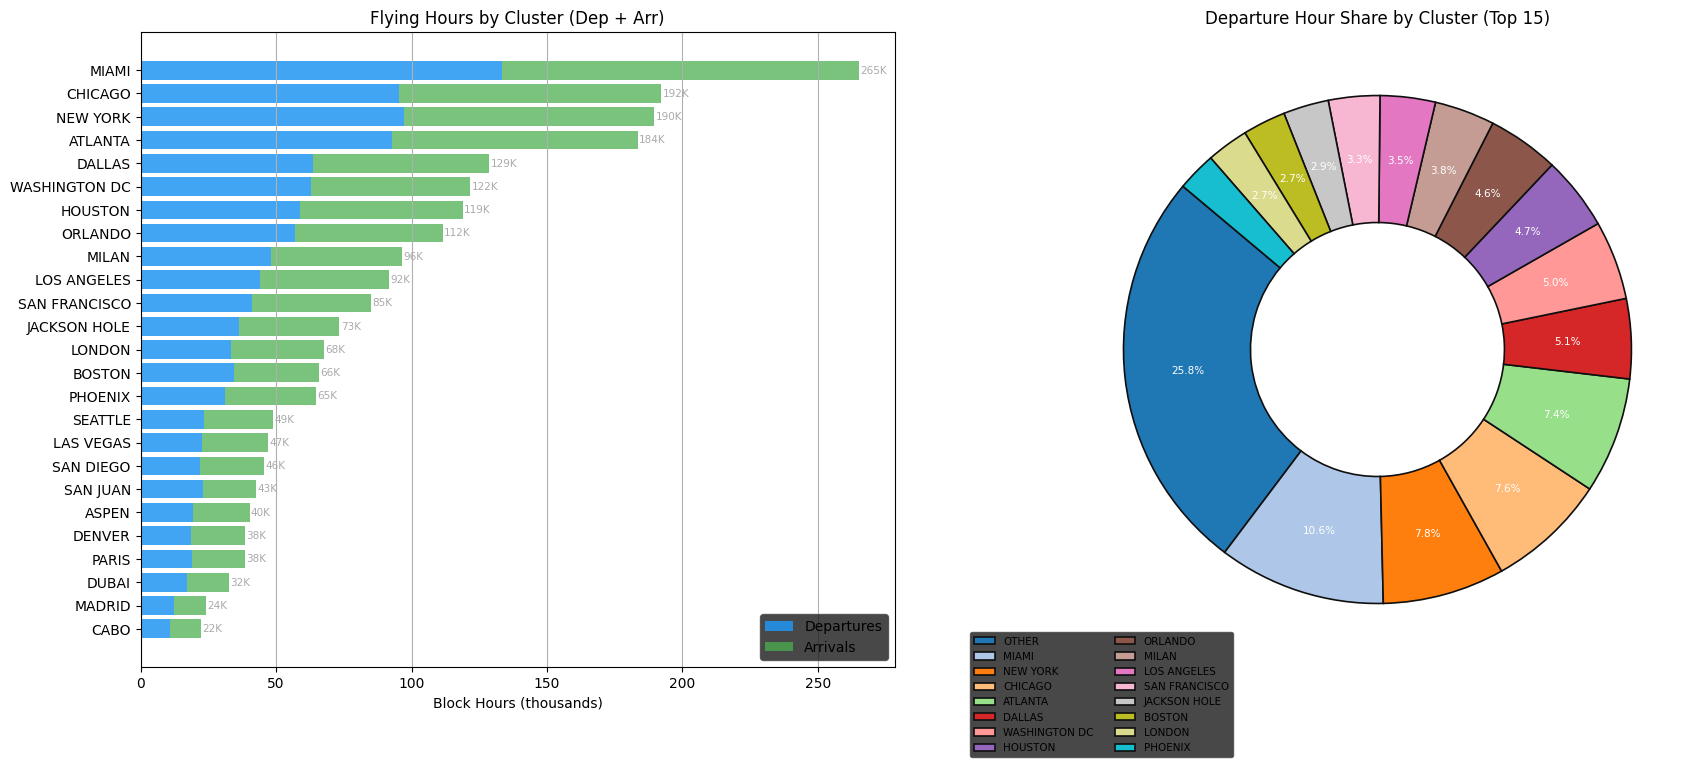

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: horizontal bar — total hours by cluster (excl OTHER) 
plot_data = cluster_hrs[cluster_hrs.index != 'OTHER_CLUSTER'].sort_values('total_hours', ascending=True).tail(25)
labels = [x.replace('_CLUSTER','').replace('_',' ') for x in plot_data.index]
colors_bar = ['#f4a261' if 'OTHER' not in x else '#555' for x in plot_data.index]

bars = axes[0].barh(labels, plot_data['dep_hours']/1000, color='#2196F3', alpha=0.85, label='Departures')
axes[0].barh(labels, plot_data['arr_hours']/1000, left=plot_data['dep_hours']/1000, color='#4CAF50', alpha=0.75, label='Arrivals')
axes[0].set_xlabel('Block Hours (thousands)')
axes[0].set_title('Flying Hours by Cluster (Dep + Arr)')
axes[0].legend(facecolor='#1a1a1a', edgecolor='#444')
axes[0].grid(axis='x')

for i, (dep, arr) in enumerate(zip(plot_data['dep_hours']/1000, plot_data['arr_hours']/1000)):
    total = dep + arr
    axes[0].text(total + 0.5, i, f'{total:.0f}K', va='center', fontsize=7.5, color='#aaa')

# Right: departure share — donut chart (top 15 clusters) 
top15 = cluster_hrs[cluster_hrs.index != 'OTHER_CLUSTER'].head(15)
rest = pd.Series({'OTHER': cluster_hrs[cluster_hrs.index.isin(['OTHER_CLUSTER'])]['dep_hours'].sum()})
donut_data = pd.concat([top15['dep_hours'], rest]).sort_values(ascending=False)
donut_labels = [x.replace('_CLUSTER','').replace('_',' ') for x in donut_data.index]

cmap = plt.get_cmap('tab20')
colors_d = [cmap(i/len(donut_data)) for i in range(len(donut_data))]
wedges, texts, autotexts = axes[1].pie(
    donut_data.values,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 2.5 else '',
    pctdistance=0.75,
    colors=colors_d,
    startangle=140,
    wedgeprops=dict(width=0.5, edgecolor='#0f0f0f', linewidth=1.2)
)
for at in autotexts:
    at.set_fontsize(7.5)
    at.set_color('white')

axes[1].legend(wedges, donut_labels, loc='lower left', bbox_to_anchor=(-0.15, -0.15),
               fontsize=7.5, ncol=2, facecolor='#1a1a1a', edgecolor='#444')
axes[1].set_title('Departure Hour Share by Cluster (Top 15)')

plt.tight_layout(pad=2)
plt.show()

In [157]:
## 3. Cluster × Cluster Route Matrix: Top origin→destination cluster pairs by total block hours — reveals the network's dominant corridors.

route_df = df_init[(df_init['from_cluster'] != 'UNMAPPED') & (df_init['to_cluster'] != 'UNMAPPED')].copy()

route_hours = (
    route_df.groupby(['from_cluster', 'to_cluster'])['Hours']
    .sum()
    .reset_index()
    .rename(columns={'Hours': 'hours'})
    .sort_values('hours', ascending=False)
)
route_hours['from_label'] = route_hours['from_cluster'].str.replace('_CLUSTER','').str.replace('_',' ')
route_hours['to_label']   = route_hours['to_cluster'].str.replace('_CLUSTER','').str.replace('_',' ')

print("Top 20 cluster-pair routes by hours:")
print(route_hours[['from_label','to_label','hours']].head(20).to_string(index=False))

Top 20 cluster-pair routes by hours:
   from_label      to_label         hours
        OTHER         OTHER 148779.225000
     NEW YORK         MIAMI  21278.060278
        MIAMI      NEW YORK  20528.022222
        OTHER         MILAN  17412.231944
        MIAMI       CHICAGO  17369.587778
        MIAMI         OTHER  16916.190278
        MILAN         OTHER  16804.895556
        OTHER         MIAMI  16747.714167
      CHICAGO         MIAMI  15928.801111
      ATLANTA       ATLANTA  15731.180000
      CHICAGO       CHICAGO  14024.530556
        MIAMI       ATLANTA  12622.466667
      ATLANTA         MIAMI  11510.750278
        DUBAI         OTHER  10659.294444
WASHINGTON DC         MIAMI  10409.012778
        OTHER        LONDON  10208.975278
        MIAMI WASHINGTON DC  10077.437222
      CHICAGO         OTHER   9720.984722
       LONDON         OTHER   9683.765000
        OTHER         DUBAI   9363.672222


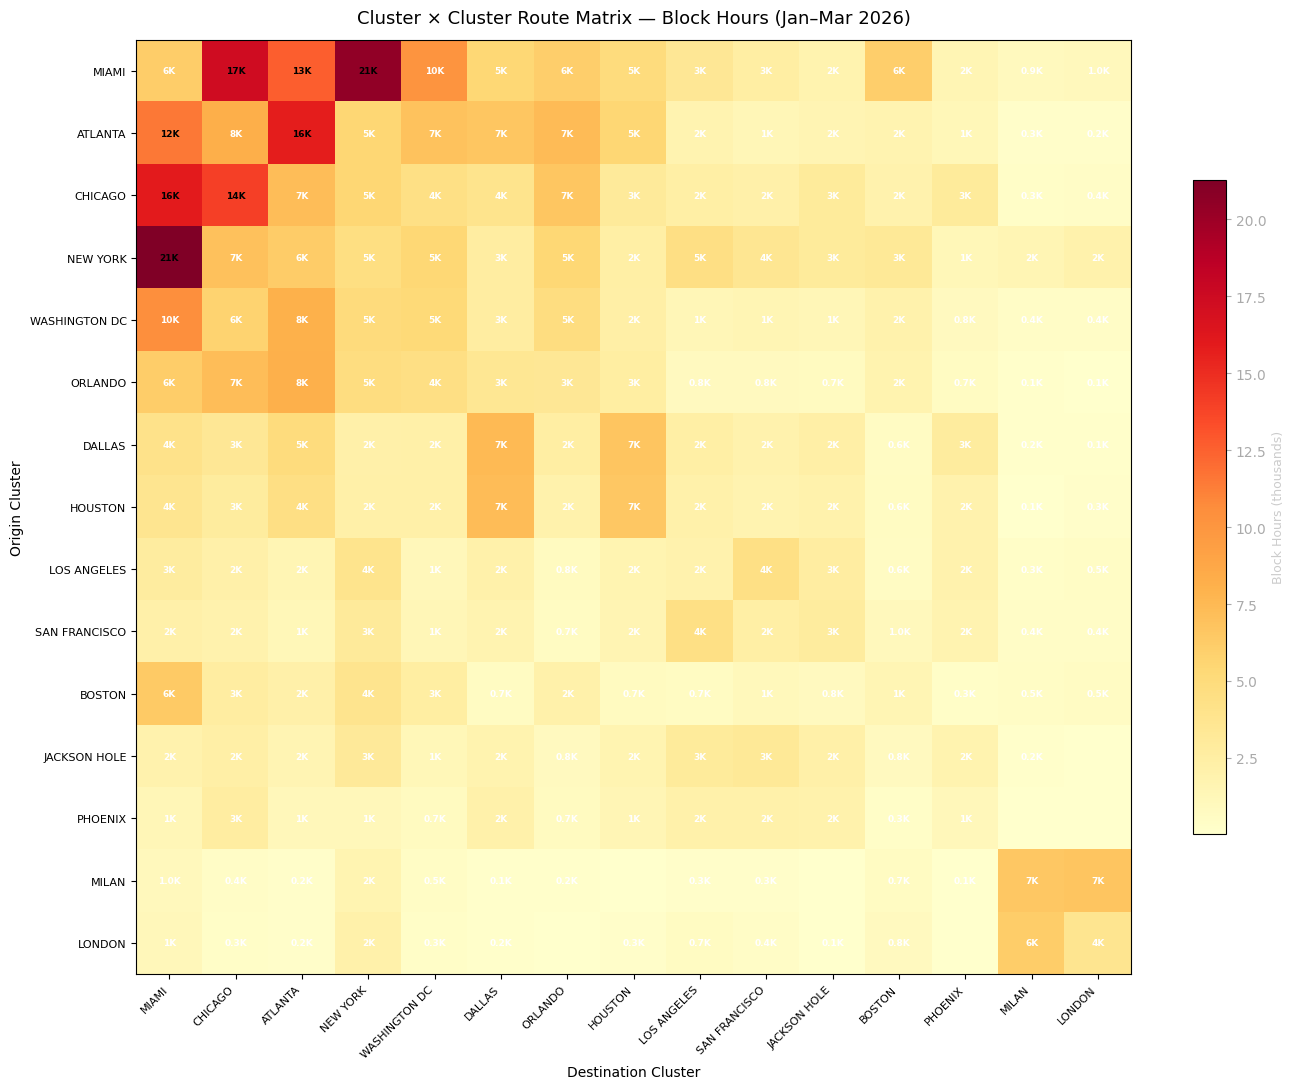

In [158]:
# Heatmap of top 15 clusters 
top_clusters = cluster_hrs[cluster_hrs.index != 'OTHER_CLUSTER'].head(15).index.tolist()

matrix = route_hours[
    route_hours['from_cluster'].isin(top_clusters) &
    route_hours['to_cluster'].isin(top_clusters)
].pivot_table(index='from_label', columns='to_label', values='hours', fill_value=0)

# Sort by total flow
order = matrix.sum(axis=1).sort_values(ascending=False).index
matrix = matrix.loc[order, :]
col_order = matrix.sum(axis=0).sort_values(ascending=False).index
matrix = matrix[col_order]

fig, ax = plt.subplots(figsize=(14, 11))

vals = matrix.values / 1000
im = ax.imshow(vals, cmap='YlOrRd', aspect='auto', interpolation='nearest')

ax.set_xticks(range(len(matrix.columns)))
ax.set_yticks(range(len(matrix.index)))
ax.set_xticklabels(matrix.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(matrix.index, fontsize=8)

for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        v = vals[i, j]
        if v > 0.1:
            color = 'black' if v > vals.max() * 0.5 else 'white'
            ax.text(j, i, f'{v:.0f}K' if v >= 1 else f'{v:.1f}K', ha='center', va='center',
                    fontsize=6.5, color=color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('Block Hours (thousands)', color='#ccc', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#aaa')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaa')

ax.set_title('Cluster × Cluster Route Matrix — Block Hours (Jan–Mar 2026)', fontsize=13, pad=12)
ax.set_xlabel('Destination Cluster', fontsize=10)
ax.set_ylabel('Origin Cluster', fontsize=10)

plt.tight_layout()
plt.show()

In [159]:
## 4. Market Share — Wheels Up vs Competition: Overall hours share, then per-cluster WU share to identify where WU is strong / weak vs market.

# Define competitor buckets 
def operator_group(op):
    op = str(op)
    if any(w in op for w in ['Wheels Up']):
        return 'Wheels Up'
    elif 'NetJets' in op:
        return 'NetJets'
    elif 'Flexjet' in op:
        return 'Flexjet'
    elif any(w in op for w in ['VistaJet','Vista America','Vista Germany','Vista']):
        return 'Vista Group'
    elif 'flyExclusive' in op:
        return 'flyExclusive'
    elif 'Executive Jet Management' in op or 'Executive AirShare' in op:
        return 'Exec Jet Mgmt'
    elif 'Solairus' in op:
        return 'Solairus'
    elif 'Jet Linx' in op:
        return 'Jet Linx'
    else:
        return 'Other'

df['operator_group'] = df['Operator'].apply(operator_group)

group_hrs = df.groupby('operator_group')['Hours'].sum().sort_values(ascending=False)
total_hrs = group_hrs.sum()
group_pct = (group_hrs / total_hrs * 100).round(2)

print("Overall Market Share by Block Hours:")
summary = pd.DataFrame({'hours': group_hrs, 'pct': group_pct})
print(summary.to_string())

# ---- Branded Charter only (WU's true competitive set) ----
bc_df = df[df['operator_type'] == 'Branded Charter'].copy()
bc_group = bc_df.groupby('operator_group')['Hours'].sum().sort_values(ascending=False)
bc_total = bc_group.sum()
bc_pct = (bc_group / bc_total * 100).round(2)
print("\nBranded Charter only — Market Share:")
bc_summary = pd.DataFrame({'hours': bc_group, 'pct': bc_pct})
print(bc_summary.to_string())

Overall Market Share by Block Hours:
                       hours    pct
operator_group                     
Other           1.083836e+06  71.45
NetJets         2.082375e+05  13.73
Flexjet         8.360867e+04   5.51
Vista Group     5.110760e+04   3.37
Exec Jet Mgmt   3.036791e+04   2.00
Solairus        1.957259e+04   1.29
flyExclusive    1.842715e+04   1.21
Wheels Up       1.255745e+04   0.83
Jet Linx        9.232225e+03   0.61

Branded Charter only — Market Share:
                        hours    pct
operator_group                      
Other           177457.989167  68.89
Vista Group      49211.502222  19.10
flyExclusive     18427.149167   7.15
Wheels Up        12507.554722   4.86


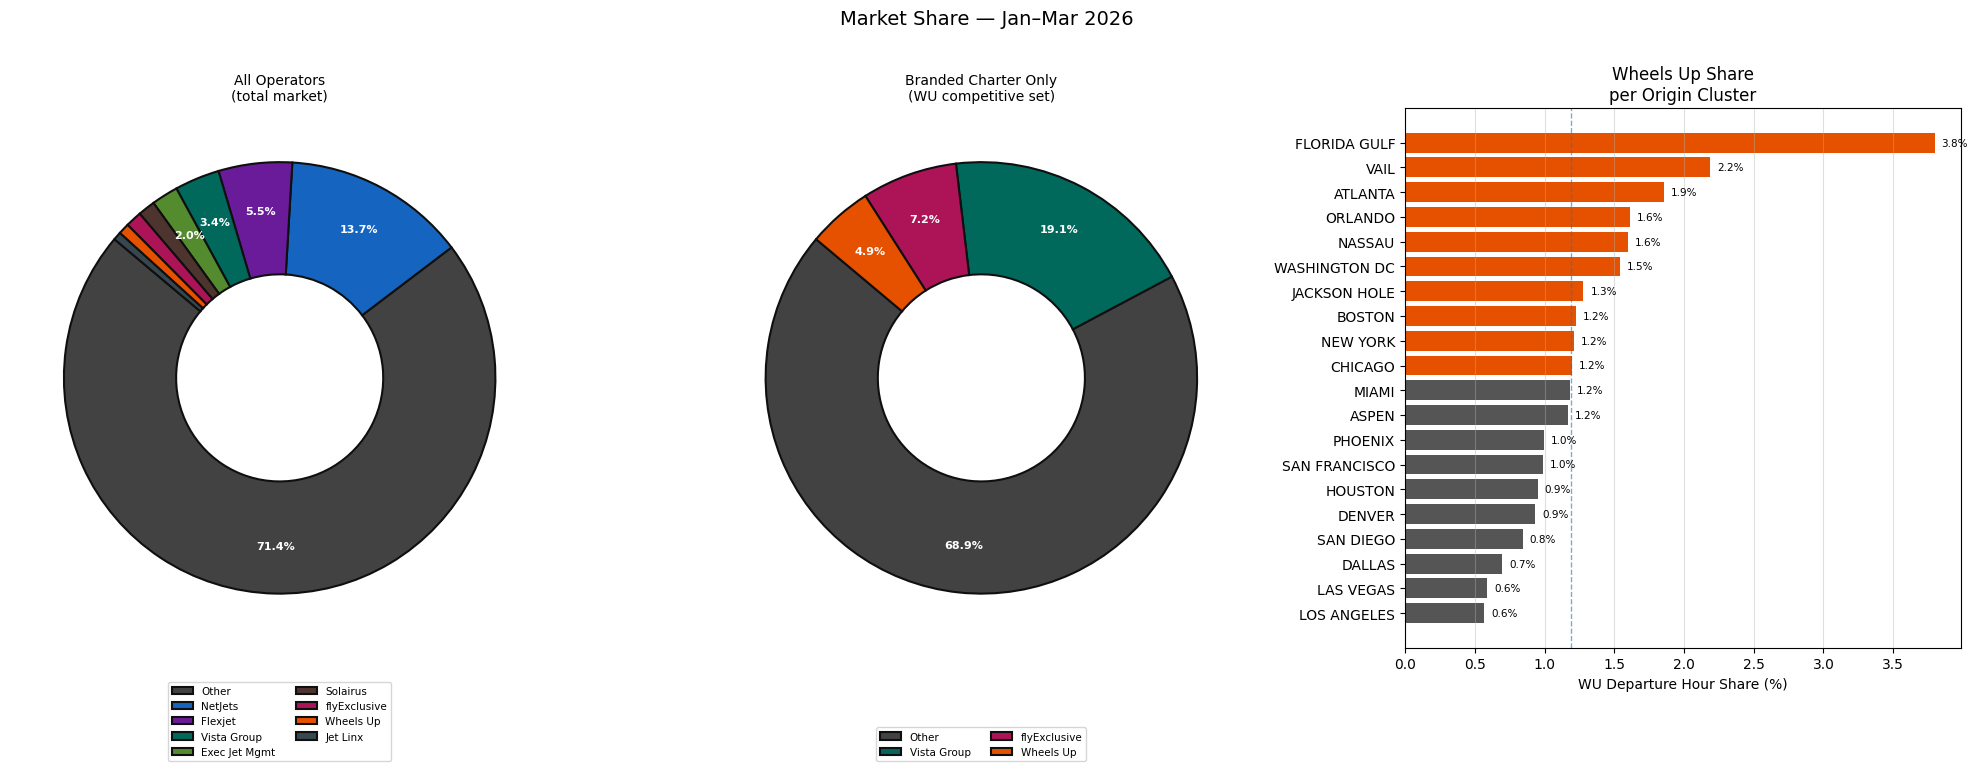

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Market Share — Jan–Mar 2026', fontsize=14, y=1.01)

PALETTE = {
    'NetJets': '#1565C0',
    'Flexjet': '#6A1B9A',
    'Vista Group': '#00695C',
    'Wheels Up': '#E65100',
    'flyExclusive': '#AD1457',
    'Exec Jet Mgmt': '#558B2F',
    'Solairus': '#4E342E',
    'Jet Linx': '#37474F',
    'Other': '#424242',
}

def get_colors(index):
    return [PALETTE.get(x, '#555') for x in index]

def plot_donut(ax, data, title):
    wedges, _, autotexts = ax.pie(
        data.values,
        colors=get_colors(data.index),
        startangle=140,
        pctdistance=0.78,
        autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
        wedgeprops=dict(width=0.52, edgecolor='#0f0f0f', linewidth=1.5)
    )
    for t in autotexts:
        t.set_fontsize(8)
        t.set_color('white')
        t.set_fontweight('bold')

    ax.legend(
        wedges, data.index,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.22),
        fontsize=7.5,
        ncol=2
    )
    ax.set_title(title, fontsize=10)

plot_donut(axes[0], group_hrs, 'All Operators\n(total market)')
plot_donut(axes[1], bc_group, 'Branded Charter Only\n(WU competitive set)')

wu_share_cluster = (
    df_init[df_init['is_wu']].groupby('from_cluster')['Hours'].sum()
    .div(df_init.groupby('from_cluster')['Hours'].sum())
    .mul(100)
    .dropna()
    .drop(['UNMAPPED', 'OTHER_CLUSTER'], errors='ignore')
)

wu_share_cluster = wu_share_cluster[wu_share_cluster > 0.05].sort_values().tail(20)
labels = wu_share_cluster.index.str.replace('_CLUSTER', '').str.replace('_', ' ')
median_val = wu_share_cluster.median()

axes[2].barh(
    labels,
    wu_share_cluster.values,
    color=['#E65100' if v > median_val else '#555' for v in wu_share_cluster.values]
)
axes[2].axvline(median_val, linestyle='--', linewidth=1, alpha=0.6)
axes[2].set_xlabel('WU Departure Hour Share (%)')
axes[2].set_title('Wheels Up Share\nper Origin Cluster')
axes[2].grid(axis='x', alpha=0.4)

for i, v in enumerate(wu_share_cluster.values):
    axes[2].text(v + 0.05, i, f'{v:.1f}%', va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

In [161]:
## 5. Seasonality Mapping: Weekly flight volume, monthly patterns, and day-of-week rhythm — Jan through Mar 2026.
import matplotlib.dates as mdates

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Daily hours — total vs WU
daily_all = df_init.groupby('date')['Hours'].sum().reset_index()
daily_wu  = df_init[df_init['is_wu']].groupby('date')['Hours'].sum().reset_index()
daily_all['date'] = pd.to_datetime(daily_all['date'])
daily_wu['date']  = pd.to_datetime(daily_wu['date'])

# DOW pattern
dow_all = df_init.groupby('dow')['Hours'].sum().reindex(DOW_ORDER)
dow_wu  = df_init[df_init['is_wu']].groupby('dow')['Hours'].sum().reindex(DOW_ORDER)
dow_pct = (dow_wu / dow_all * 100).fillna(0)

# Monthly
mon_all = df_init.groupby('month_name')['Hours'].sum().reindex(['Jan','Feb','Mar'])
mon_wu  = df_init[df_init['is_wu']].groupby('month_name')['Hours'].sum().reindex(['Jan','Feb','Mar'])

# Aircraft segment distribution — WU vs market
seg_all = df_init.groupby('aircraft_segment')['Hours'].sum().sort_values(ascending=False)
seg_wu  = df_init[df_init['is_wu']].groupby('aircraft_segment')['Hours'].sum().reindex(seg_all.index).fillna(0)
seg_wu_pct = (seg_wu / seg_all * 100).fillna(0)

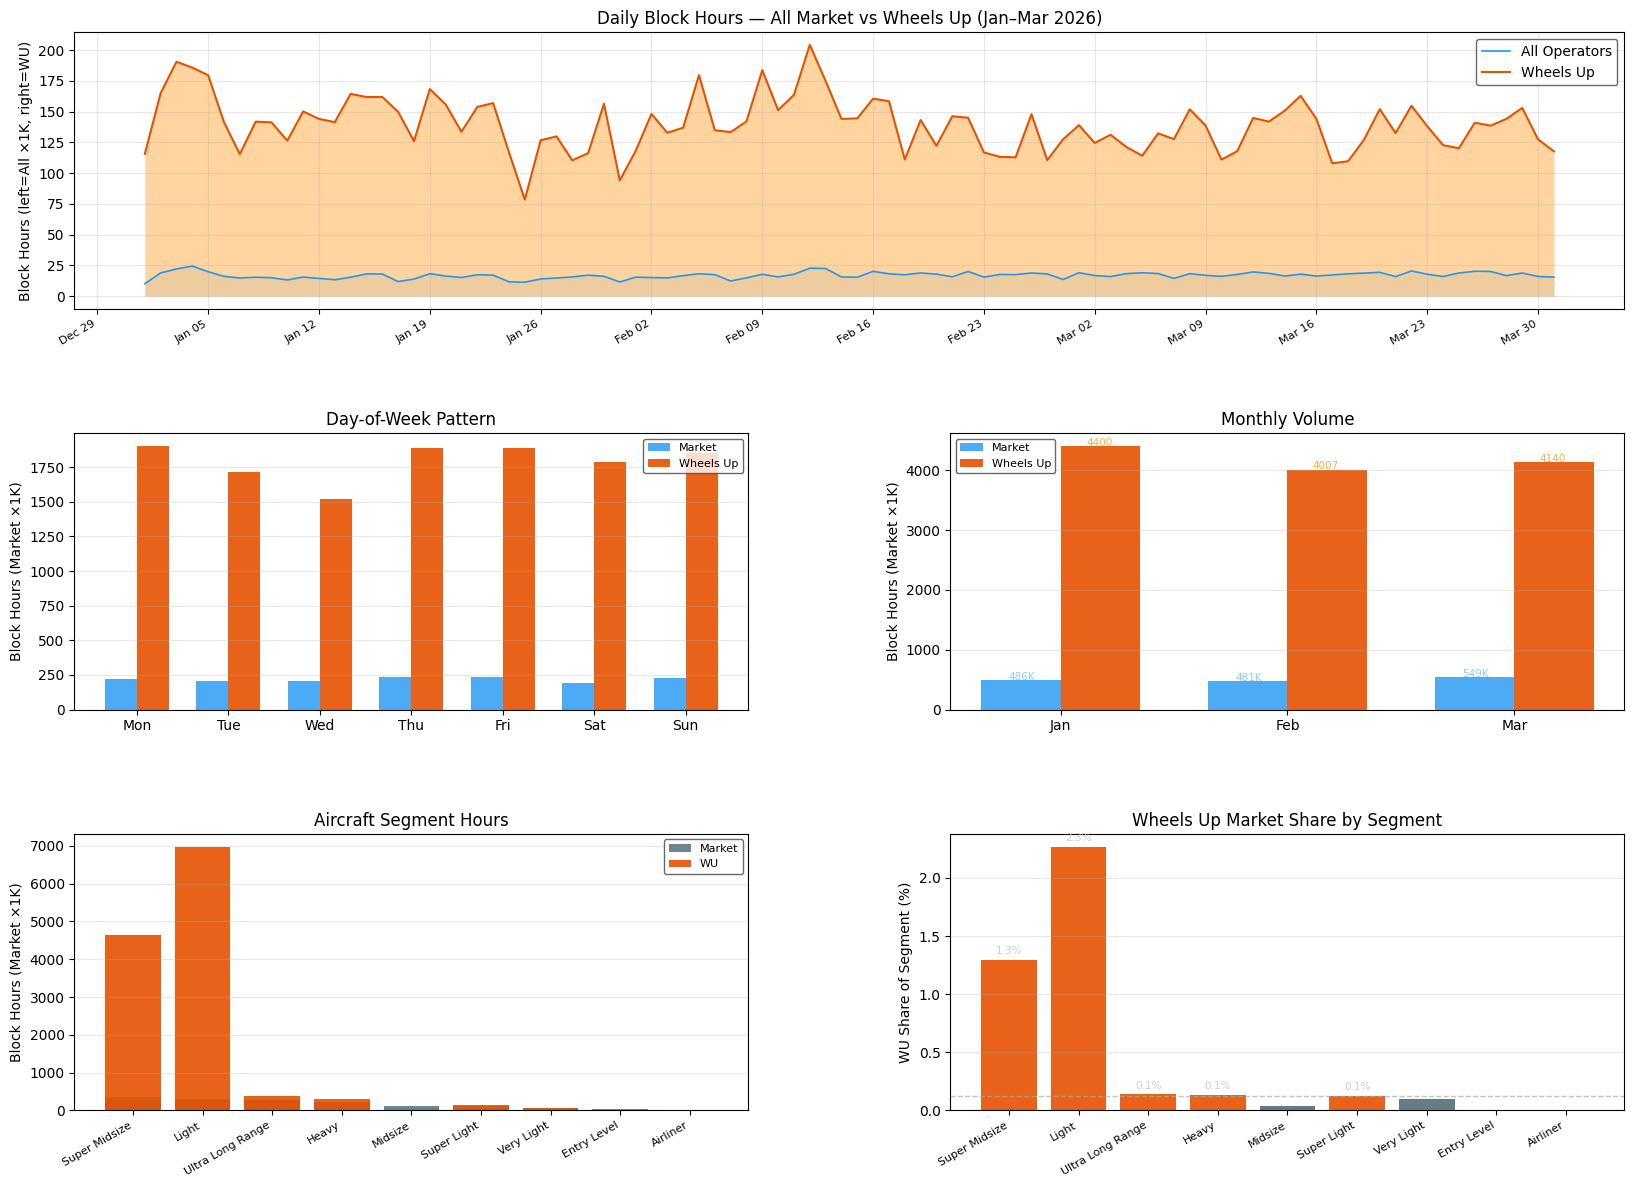

In [162]:
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# 1: Daily flight hours time series 
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(daily_all['date'], daily_all['Hours']/1000, alpha=0.3, color='#90CAF9', linewidth=0)
ax1.plot(daily_all['date'], daily_all['Hours']/1000, color='#2196F3', linewidth=1.2, label='All Operators')
ax1.fill_between(daily_wu['date'], daily_wu['Hours'], alpha=0.5, color='#FFAB40', linewidth=0)
ax1.plot(daily_wu['date'], daily_wu['Hours'], color='#E65100', linewidth=1.5, label='Wheels Up', zorder=5)
ax1.set_ylabel('Block Hours (left=All ×1K, right=WU)')
ax1.set_title('Daily Block Hours — All Market vs Wheels Up (Jan–Mar 2026)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
ax1.legend(edgecolor='#444')
ax1.grid(alpha=0.3)

# 2: Day of week pattern 
ax2 = fig.add_subplot(gs[1, 0])
x = np.arange(len(DOW_ORDER))
w = 0.35
ax2.bar(x - w/2, dow_all.values/1000, w, color='#2196F3', alpha=0.8, label='Market')
ax2.bar(x + w/2, dow_wu.values, w, color='#E65100', alpha=0.9, label='Wheels Up')
ax2.set_xticks(x)
ax2.set_xticklabels([d[:3] for d in DOW_ORDER])
ax2.set_ylabel('Block Hours (Market ×1K)')
ax2.set_title('Day-of-Week Pattern')
ax2.legend(edgecolor='#444', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# 3: Monthly hours 
ax3 = fig.add_subplot(gs[1, 1])
months = ['Jan','Feb','Mar']
x = np.arange(3)
ax3.bar(x - w/2, mon_all.values/1000, w, color='#2196F3', alpha=0.8, label='Market')
ax3.bar(x + w/2, mon_wu.values, w, color='#E65100', alpha=0.9, label='Wheels Up')
ax3.set_xticks(x); ax3.set_xticklabels(months)
ax3.set_ylabel('Block Hours (Market ×1K)')
ax3.set_title('Monthly Volume')
ax3.legend(edgecolor='#444', fontsize=8)
ax3.grid(axis='y', alpha=0.3)
for i, (m, w2) in enumerate(zip(mon_all.values/1000, mon_wu.values)):
    ax3.text(i - 0.17, m + 0.3, f'{m:.0f}K', ha='center', fontsize=7.5, color='#90CAF9')
    ax3.text(i + 0.17, w2 + 5, f'{w2:.0f}', ha='center', fontsize=7.5, color='#FFAB40')

# 4: Aircraft segment hours — market share 
ax4 = fig.add_subplot(gs[2, 0])
segs = seg_all.index.tolist()
x = np.arange(len(segs))
ax4.bar(x, seg_all.values/1000, color='#546E7A', alpha=0.85, label='Market')
ax4.bar(x, seg_wu.values, color='#E65100', alpha=0.9, label='WU')
ax4.set_xticks(x)
ax4.set_xticklabels([s.replace(' Jet','').replace('Airliner/Bizliner(Jet)','Airliner') for s in segs],
                    rotation=30, ha='right', fontsize=8)
ax4.set_ylabel('Block Hours (Market ×1K)')
ax4.set_title('Aircraft Segment Hours')
ax4.legend( edgecolor='#444', fontsize=8)
ax4.grid(axis='y', alpha=0.3)

# 5: WU segment share % 
ax5 = fig.add_subplot(gs[2, 1])
colors_seg = ['#E65100' if v >= seg_wu_pct.median() else '#546E7A' for v in seg_wu_pct.values]
ax5.bar(x, seg_wu_pct.values, color=colors_seg, alpha=0.9)
ax5.axhline(seg_wu_pct.median(), color='#aaa', linestyle='--', linewidth=1, alpha=0.7)
ax5.set_xticks(x)
ax5.set_xticklabels([s.replace(' Jet','').replace('Airliner/Bizliner(Jet)','Airliner') for s in segs],
                    rotation=30, ha='right', fontsize=8)
ax5.set_ylabel('WU Share of Segment (%)')
ax5.set_title('Wheels Up Market Share by Segment')
ax5.grid(axis='y', alpha=0.3)
for i, v in enumerate(seg_wu_pct.values):
    if v > 0.1:
        ax5.text(i, v + 0.05, f'{v:.1f}%', ha='center', fontsize=7.5, color='#ccc')

plt.show()


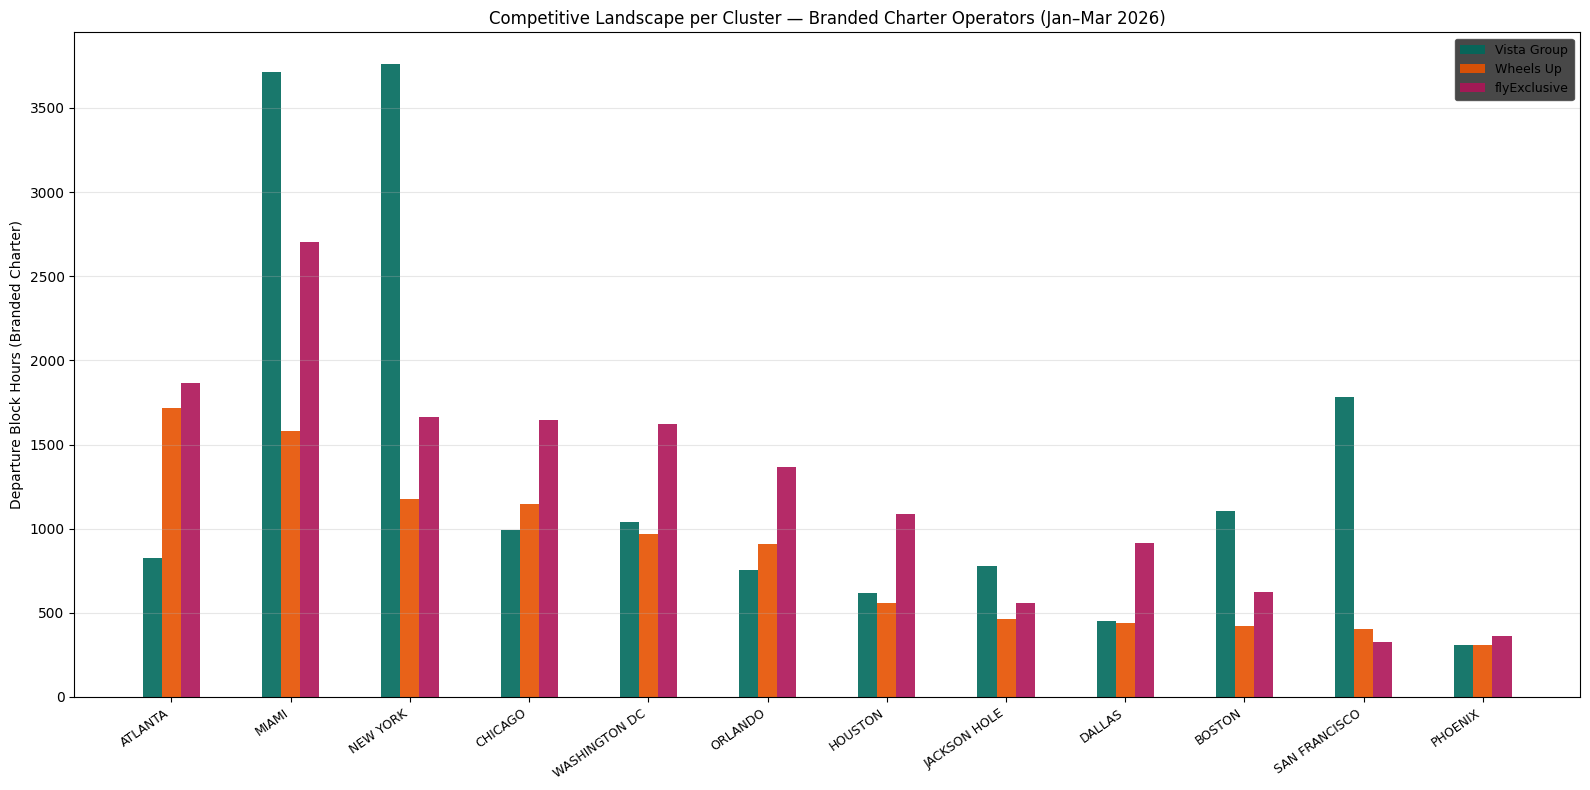

In [164]:
## 6. WU Competitive Position — Cluster Deep Dive: Per-cluster: WU hours vs top 5 competitors. Identifies where WU leads, trails, or is absent.
# top 12 WU clusters by WU departure hours
wu_by_cluster = df_init[df_init['is_wu']].groupby('from_cluster')['Hours'].sum()
wu_by_cluster = wu_by_cluster.drop(index=['UNMAPPED','OTHER_CLUSTER'], errors='ignore')
top_wu_clusters = wu_by_cluster.sort_values(ascending=False).head(12).index.tolist()

# Competitor hours per cluster (branded charter only for clean comparison)
bc_comp = df_init[(df_init['operator_type'] == 'Branded Charter') & (df_init['from_cluster'].isin(top_wu_clusters))].copy()
comp_cluster = bc_comp.groupby(['from_cluster','operator_group'])['Hours'].sum().reset_index()

KEY_GROUPS = ['NetJets','Flexjet','Vista Group','Wheels Up','flyExclusive']
comp_pivot = comp_cluster[comp_cluster['operator_group'].isin(KEY_GROUPS)].pivot_table(
    index='from_cluster', columns='operator_group', values='Hours', fill_value=0
)
comp_pivot = comp_pivot.reindex(top_wu_clusters).fillna(0)
comp_pivot.index = [x.replace('_CLUSTER','').replace('_',' ') for x in comp_pivot.index]

fig, ax = plt.subplots(figsize=(16, 8))


x = np.arange(len(comp_pivot))
bar_w = 0.16
groups = [c for c in KEY_GROUPS if c in comp_pivot.columns]
offsets = np.linspace(-(len(groups)-1)/2, (len(groups)-1)/2, len(groups)) * bar_w

for grp, off in zip(groups, offsets):
    color = PALETTE.get(grp, '#666')
    ax.bar(x + off, comp_pivot[grp].values, bar_w,
           color=color, alpha=0.9, label=grp, edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(comp_pivot.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Departure Block Hours (Branded Charter)')
ax.set_title('Competitive Landscape per Cluster — Branded Charter Operators (Jan–Mar 2026)', fontsize=12)
ax.legend(facecolor='#1a1a1a', edgecolor='#444', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [166]:
## 7. Summary Table — Key Numbers: Quick reference: all clusters ranked, with WU share, total hours, and WU hours.

wu_dep_hrs  = df_init[df_init['is_wu']].groupby('from_cluster')['Hours'].sum().rename('wu_dep_hours')
all_dep_hrs = df_init.groupby('from_cluster')['Hours'].sum().rename('total_dep_hours')
wu_arr_hrs  = df_init[df_init['is_wu']].groupby('to_cluster')['Hours'].sum().rename('wu_arr_hours')
all_arr_hrs = df_init.groupby('to_cluster')['Hours'].sum().rename('total_arr_hours')

summary_tbl = pd.concat([all_dep_hrs, wu_dep_hrs, all_arr_hrs, wu_arr_hrs], axis=1).fillna(0)
summary_tbl = summary_tbl.drop(index=['UNMAPPED'], errors='ignore')
summary_tbl['total_hours'] = summary_tbl['total_dep_hours'] + summary_tbl['total_arr_hours']
summary_tbl['wu_hours']    = summary_tbl['wu_dep_hours'] + summary_tbl['wu_arr_hours']
summary_tbl['wu_share_pct'] = (summary_tbl['wu_hours'] / summary_tbl['total_hours'] * 100).round(2)
summary_tbl.index = [x.replace('_CLUSTER','').replace('_',' ') for x in summary_tbl.index]
summary_tbl = summary_tbl.sort_values('total_hours', ascending=False)

out = summary_tbl[['total_hours','wu_hours','wu_share_pct']].copy()
out.columns = ['Total Hours', 'WU Hours', 'WU Share %']
out['Total Hours'] = out['Total Hours'].round(0).astype(int)
out['WU Hours'] = out['WU Hours'].round(0).astype(int)

print("=== Cluster Summary Table ===")
print(out.to_string())

print(f"\n=== KEY STATS ===")
print(f"Total market hours (Jan-Mar 2026): {df_init['Hours'].sum():,.0f}")
print(f"Wheels Up hours: {df_init[df_init['is_wu']]['Hours'].sum():,.0f}")
print(f"WU overall market share: {df_init[df_init['is_wu']]['Hours'].sum()/df_init['Hours'].sum()*100:.2f}%")
bc_total_h = df_init[df_init['operator_type']=='Branded Charter']['Hours'].sum()
wu_bc_h = df_init[df_init['is_wu'] & (df_init['operator_type']=='Branded Charter')]['Hours'].sum()
print(f"WU share within Branded Charter: {wu_bc_h/bc_total_h*100:.2f}%")
print(f"\nTotal flights: {len(df_init):,}")
print(f"WU flights: {df_init['is_wu'].sum():,}")

=== Cluster Summary Table ===
               Total Hours  WU Hours  WU Share %
OTHER               647840      1666        0.26
MIAMI               265053      3189        1.20
CHICAGO             192199      2282        1.19
NEW YORK            189654      2247        1.18
ATLANTA             183519      3437        1.87
DALLAS              128613       915        0.71
WASHINGTON DC       121685      1866        1.53
HOUSTON             118897      1130        0.95
ORLANDO             111541      1814        1.63
MILAN                96476        11        0.01
LOS ANGELES          91540       545        0.60
SAN FRANCISCO        84988       840        0.99
JACKSON HOLE         73398       930        1.27
LONDON               67591        12        0.02
BOSTON               65989       814        1.23
PHOENIX              64645       667        1.03
SEATTLE              48809       208        0.43
LAS VEGAS            46955       290        0.62
SAN DIEGO            45581       379   